### Introduction to Regression with Neural Networks in TensorFlow


There are many definition for a regression problem but in our case, we're going to simplify it: predicting a numerical variable based on some other combination of a variable, even shorter... predicting a number.

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


## creating data to view and fit it

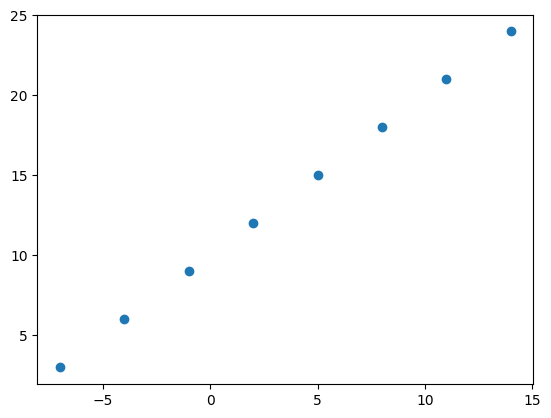

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# create features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])


# create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# vizualize the data
plt.scatter(x,y);

In [ ]:
y == x + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

## Input and Output shapes

In [ ]:
# create a demo tensor for our housing price prediction problem

house_info = tf.constant(["bedroom","bathroom","garage"])
house_price = tf.constant([939700])
house_info,house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [ ]:
input_shape = x.shape
output_shape = y.shape
input_shape,output_shape

((8,), (8,))

### Turn our Numpy array into tensors




## steps on modeling with tensorflow

1. **creating a model** - defining the input and output layers, as well as the hidden layers of a deep learning model.

2. **compiling a model** - define the loss function (in other words, the function wihich tells our model how wrong it is) and the optimizer (tells our model how to improve patterns its learning) and evaluations metrics (what we can use to interpret the performance of our model).

3. **fitting a model** - letting the model try to find patterns between x and y (features and labels|)

In [ ]:
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

x = tf.constant(x, dtype=tf.float32)
y = tf.constant(y, dtype=tf.float32)
x,y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
# set random seed
tf.random.set_seed(42)

# create a model using the sequential API

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. compile the model
model.compile(loss=tf.keras.losses.mae, # mean absolute error (comaprison betweeen predictied vs observed)
              optimizer=tf.keras.optimizers.SGD(), # short of stochastic gradient decent
              metrics=["mae"])

# fit the model
model.fit(tf.expand_dims(x, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 15.5083 - mae: 15.5083
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 15.2271 - mae: 15.2271
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - loss: 14.9564 - mae: 14.9564
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 14.8239 - mae: 14.8239
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - loss: 14.6914 - mae: 14.6914


In [ ]:
# try and make a prediction using our model

model.predict(tf.expand_dims(tf.constant([17.0], dtype=tf.float32), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


array([[-5.316705]], dtype=float32)

## Improving our model

We can improve our model by altering the steps we took to create it.


1. **Creating a model** = Here we might add more layers, increase the number of hidden units (also called neurons) within each of the hidden layers, or change the activation function of each layer.

2. **Compiling a model** = Here we might change the optimizer function or perhaps the learning rate of the optimizer function.

3. **Fitting a model** = Here we might fit a model for more epochs (leave it training for longer) or on more data (give the model more examples to learn from).

In [ ]:
# lts rebuild our model

# 1. create a model

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1) ])
# compile the model

model.compile(loss=tf.keras.losses.mae,
              optimizer= tf.keras.optimizers.SGD(),
              metrics=['mae'])

# 3. fit the model
model.fit(tf.expand_dims(x, axis=-1),y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 10.1635 - mae: 10.1635
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 10.0310 - mae: 10.0310
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 9.8985 - mae: 9.8985
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 9.7660 - mae: 9.7660
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 9.6335 - mae: 9.6335
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 9.5010 - mae: 9.5010
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 9.3685 - mae: 9.3685
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 9.2360 - mae: 9.2360
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 9.1035 - mae: 9.1035
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 8.9710 - mae: 8.9710
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 8.8385 - mae: 8.8385
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 8.7060 - mae: 8.7060
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# remind yourself data
print(x)
print(y)

tf.Tensor([-7. -4. -1.  2.  5.  8. 11. 14.], shape=(8,), dtype=float32)
tf.Tensor([ 3.  6.  9. 12. 15. 18. 21. 24.], shape=(8,), dtype=float32)


In [ ]:
# lets see if our model prediction has improved ---> correct value is 27
model.predict(tf.expand_dims(tf.constant([17.0], dtype=tf.float32), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


array([[30.10065]], dtype=float32)

In [ ]:
from sys import activate_stack_trampoline
# lets see if we can make another to improve our model

# 1. create the model (this time with an extra hidden layer with 100 units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(1) ])

# compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer= tf.keras.optimizers.SGD(),
              metrics=['mae'])

# 3. fit the model
model.fit(tf.expand_dims(x, axis=-1),y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step - loss: 13.6258 - mae: 13.6258
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 13.0547 - mae: 13.0547
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.4871 - mae: 12.4871
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 11.9196 - mae: 11.9196
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 11.3480 - mae: 11.3480
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 10.7735 - mae: 10.7735
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 10.1863 - mae: 10.1863
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 9.5748 - mae: 9.5748
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 8.9308 - mae: 8.9308
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8.2511 - mae: 8.2511
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 7.5248 - mae: 7.5248
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 6.7472 - mae: 6.7472
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━

In [ ]:
# lets see if our model prediction has improved after this ---> correct value is 27
model.predict(tf.expand_dims(tf.constant([17.0], dtype=tf.float32), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([[32.346966]], dtype=float32)

### Changing Activation to None


In [ ]:
# changing activation func may help ?

# 1. create the model (this time with an extra hidden layer with 100 units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50,activation=None),
    tf.keras.layers.Dense(1) ])

# compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer= tf.keras.optimizers.SGD(),
              metrics=['mae'])

# 3. fit the model
model.fit(tf.expand_dims(x, axis=-1),y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step - loss: 15.8016 - mae: 15.8016
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 14.8016 - mae: 14.8016
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 14.3101 - mae: 14.3101
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 13.8243 - mae: 13.8243
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 13.3416 - mae: 13.3416
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 12.8595 - mae: 12.8595
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 12.3756 - mae: 12.3756
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 11.8872 - mae: 11.8872
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 11.3919 - mae: 11.3919
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 10.8871 - mae: 10.8871
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 10.3703 - mae: 10.3703
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 9.8387 - mae: 9.8387
Epoch 13/100
1/1 ━━━━━━━━━

In [ ]:
# lets see if our model prediction has improved after this ---> correct value is 27
model.predict(tf.expand_dims(tf.constant([17.0], dtype=tf.float32), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


array([[30.344145]], dtype=float32)

### Changing Optimizer

In [ ]:
# changing activation func may help ?

# 1. create the model (this time with an extra hidden layer with 100 units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100,activation=None),
    tf.keras.layers.Dense(1) ])

# compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['mae'])

# 3. fit the model
model.fit(tf.expand_dims(x, axis=-1),y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 13.4694 - mae: 13.4694
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 12.4883 - mae: 12.4883
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 11.5003 - mae: 11.5003
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 10.4995 - mae: 10.4995
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 9.4815 - mae: 9.4815
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 8.4408 - mae: 8.4408
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 7.3716 - mae: 7.3716
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 6.7558 - mae: 6.7558
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 7.2478 - mae: 7.2478
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 7.8273 - mae: 7.8273
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 8.0556 - mae: 8.0556
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 7.9432 - mae: 7.9432
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68

## YAY we did it 27 is the correct value

In [ ]:
# lets see if our model prediction has improved after this ---> correct value is 27
model.predict(tf.expand_dims(tf.constant([17.0], dtype=tf.float32), axis=-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


array([[27.830706]], dtype=float32)

## Evaluating the model

In practice, a typical workflow when building a neural network is:

```building a model -> fit it -> evaluate it -> tweak it -> repeat as needed```

## When it comes to evaluation, there are 3 words you should memorize:

**"Visualize", "Visualize", "Visualize"**

To properly evaluate your model, you need to visualize:

*   **The data**: What data are we working with? What does it look like?
*   **The model itself**: What does our model look like (its architecture)?
*   **The training of a model**: How does the model perform while it learns?
*   **The predictions of a model**: How do the model's predictions align with the ground truth (the original labels)?

In [ ]:
# make a bigger dataset

x = tf.range(-100,100,4)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [ ]:
# make labels for the dataset

y = x + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

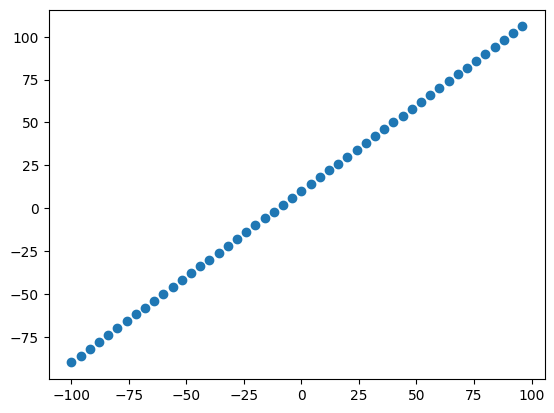

In [ ]:
# vizualize the data

import matplotlib.pyplot as plt

plt.scatter(x,y)

### The 3 sets of data

When working with machine learning models, it's crucial to split your data into three distinct sets:

*   **Training set**: Used to train the model.
*   **Validation set**: Used to tune the model's hyperparameters and prevent overfitting during training.
*   **Test set**: Used to evaluate the final performance of the model on unseen data.

In [ ]:
# split the data into train and test sets

x_train = x[:40] # first 40 are training sample 80% of the data
y_train = y[:40]

x_test = x[40:] # last 10 are testing sample 20% of the data
y_test = y[40:] # This should be y[40:] to get the corresponding labels

len(x_train),len(y_train),len(x_test),len(y_test),

(40, 40, 10, 10)

### vizualizing the data

now we've got our data in training and test sets. lets visualize it again

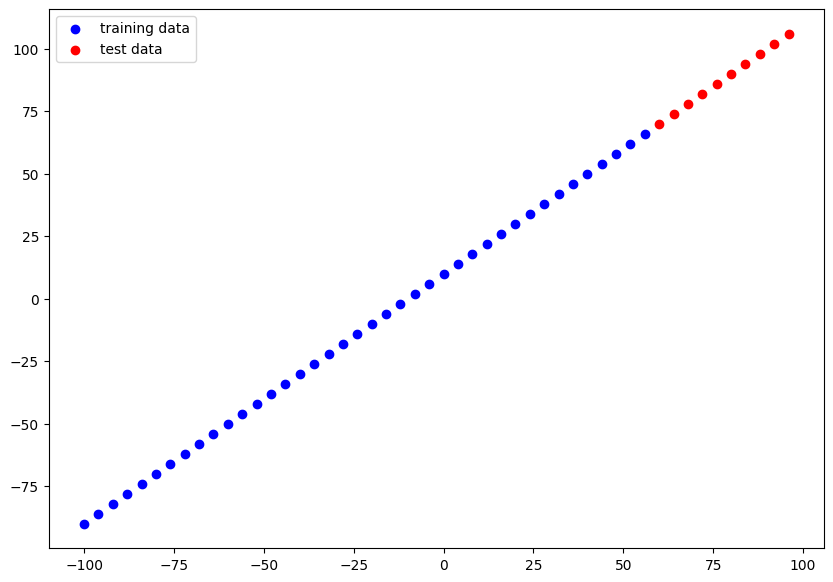

In [ ]:
plt.figure(figsize=(10,7))

# plot training data in blue
plt.scatter(x_train,y_train,c="b",label="training data")

# plot test data in red
plt.scatter(x_test,y_test,c="r",label="test data")

# show legend
plt.legend();

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. compile the  model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['mae'])
# fit model
model.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=500 , verbose=0)

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 905 (3.54 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 604 (2.36 KB)

In [ ]:
# plot_model(model=model,show_shapes=True)

### visualize our model's predictions

to visualize predictions, its good idea to plot them against the ground truth labels


often you'll see this in the form of y_test or y_true versus y_pred (ground truth vs model's predictions)



In [ ]:
# make some predictions

y_pred = model.predict(x_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[ 69.99404 ],
       [ 74.20016 ],
       [ 78.40627 ],
       [ 82.61237 ],
       [ 86.82059 ],
       [ 91.030334],
       [ 95.24008 ],
       [ 99.449814],
       [103.65956 ],
       [107.86931 ]], dtype=float32)

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

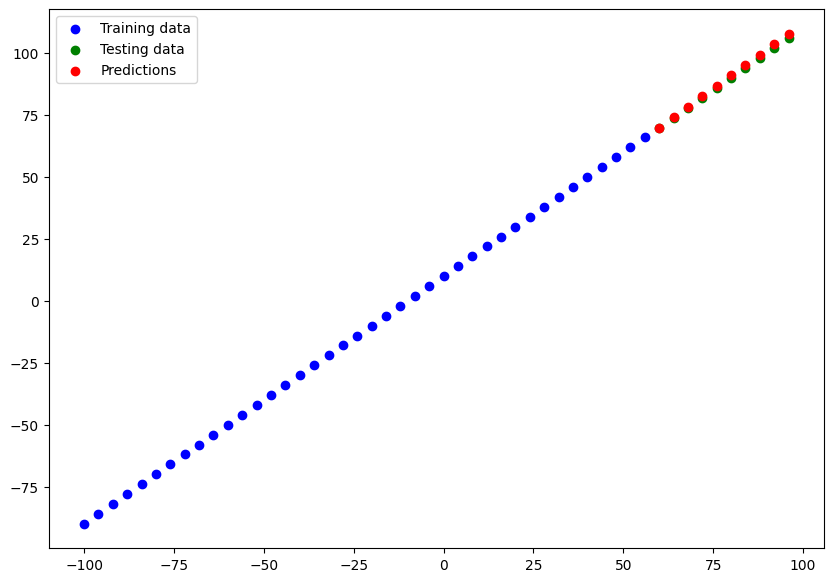

In [ ]:
# lets create a plotting function

def plot_predictions(train_data, train_labels, test_data, test_labels, predictions):
  """ Plots training data, test data and compares predictions to ground truth labels. """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c='b', label='Training data')
  # Plot testing data in green
  plt.scatter(test_data, test_labels, c='g', label='Testing data')
  # Plot model's predictions in red
  plt.scatter(test_data, predictions, c='r', label='Predictions')
  # Show the legend
  plt.legend()
  plt.show()


plot_predictions(x_train, y_train, x_test, y_test, y_pred)

## Evaluate our model with Regression Evaluation Metrics

Depending on the problem you're working on, there will be different evaluation metrics to assess your model's performance. For regression problems, two main metrics are commonly used:

*   **MAE (Mean Absolute Error)**: On average, how wrong is each of your model's predictions?
*   **MSE (Mean Squared Error)**: Similar to MAE, but it squares the errors before averaging them. This gives larger errors more weight and is useful when larger errors are particularly undesirable.

In [ ]:
# evaluate the model on test

model.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.9294 - mae: 0.9294


[0.9294449090957642, 0.9294449090957642]

In [ ]:
# calcualte the mean absolute error
mae = tf.keras.losses.MAE(y_test,y_pred)
np.mean(mae)


np.float32(0.9294449)

In [ ]:
# Calculate the Mean Squared Error
mse = tf.keras.losses.MSE(y_test, y_pred)
print(f"Mean Squared Error: {np.mean(mse)}")

Mean Squared Error: 1.2203329801559448


### Running experiments to improve our model

build model -> fit it -> evaluate it -> tweek it -> fit it -> evaluate it


1. get more data

2. make your model larger using complex model more hidden units or more layers

3. train for longer give your model more of a chance to find pattern in the data


## Lets do 3 modelling expriments:

1. `model 1` same as original model 1 layer trained for 100 epochs

2. `model 2` 2 layer trained for 100 epochs

3. `model 3` 2 layer trained for 500 epochs


you can create you 4 5 6 whatever

In [ ]:
# set the random seed
tf.random.set_seed(27)

# create model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # Explicitly define input shape for clarity
])

# 2. compile the  model_1
model_1.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              metrics=['mae'])
# fit model_1
model_1.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=100 , verbose=1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 28.8340 - mae: 28.8340 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.0635 - mae: 8.0635
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 11.9926 - mae: 11.9926
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 12.8333 - mae: 12.8333
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 10.9075 - mae: 10.9075
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 10.2165 - mae: 10.2165
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.3048 - mae: 9.3048
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.8269 - mae: 9.8269
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9.6905 - mae: 9.6905
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.3973 - mae: 9.3973
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 9.9394 - mae: 9.9394
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 9.8029 - mae: 9.8029
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


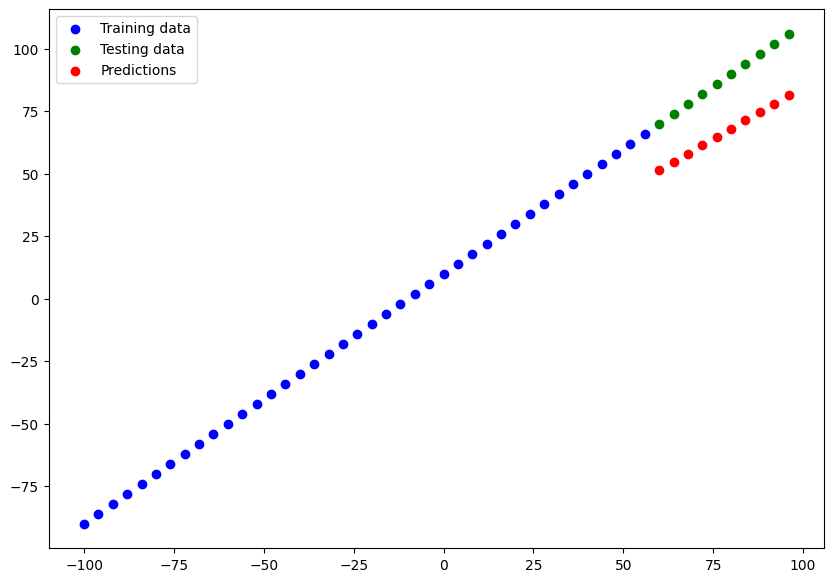

In [ ]:
# make and plot predictions for model 1

y_preds_1 = model_1.predict(tf.expand_dims(x_test, axis=-1))
plot_predictions(train_data=x_train, train_labels=y_train, test_data=x_test, test_labels=y_test, predictions=y_preds_1)

In [ ]:
# Evaluate model_1

print("Evaluating model_1...")
mae_1 = tf.keras.losses.MAE(y_test, tf.squeeze(y_preds_1))
mse_1 = tf.keras.losses.MSE(y_test, tf.squeeze(y_preds_1))
print(f"MAE for model_1: {tf.reduce_mean(mae_1).numpy():.2f}")
print(f"MSE for model_1: {tf.reduce_mean(mse_1).numpy():.2f}")

Evaluating model_1...
MAE for model_1: 21.63
MSE for model_1: 471.37


### Experiment 2: `model_2` (2 layers, 100 epochs)

In [ ]:
# set the random seed
tf.random.set_seed(42)

# create model_2 (2 dense layers)
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. compile model_2
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mse'])

# fit model_2
print("Fitting model_2...")
model_2.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=100, verbose=2)




Fitting model_2...
Epoch 1/100
2/2 - 1s - 313ms/step - loss: 55.4564 - mse: 4739.2520
Epoch 2/100
2/2 - 0s - 27ms/step - loss: 28.4002 - mse: 1123.4512
Epoch 3/100
2/2 - 0s - 27ms/step - loss: 24.3938 - mse: 820.2990
Epoch 4/100
2/2 - 0s - 29ms/step - loss: 19.6562 - mse: 533.4169
Epoch 5/100
2/2 - 0s - 27ms/step - loss: 17.5972 - mse: 430.7701
Epoch 6/100
2/2 - 0s - 27ms/step - loss: 16.4668 - mse: 373.9374
Epoch 7/100
2/2 - 0s - 30ms/step - loss: 11.9925 - mse: 234.4405
Epoch 8/100
2/2 - 0s - 27ms/step - loss: 15.3221 - mse: 328.2670
Epoch 9/100
2/2 - 0s - 29ms/step - loss: 15.8937 - mse: 341.3756
Epoch 10/100
2/2 - 0s - 27ms/step - loss: 12.4528 - mse: 241.0192
Epoch 11/100
2/2 - 0s - 28ms/step - loss: 15.0379 - mse: 313.4070
Epoch 12/100
2/2 - 0s - 30ms/step - loss: 11.5642 - mse: 216.6490
Epoch 13/100
2/2 - 0s - 29ms/step - loss: 14.9335 - mse: 309.3372
Epoch 14/100
2/2 - 0s - 27ms/step - loss: 11.5179 - mse: 215.0778
Epoch 15/100
2/2 - 0s - 30ms/step - loss: 14.8898 - mse: 307.54

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Plotting predictions for model_2...


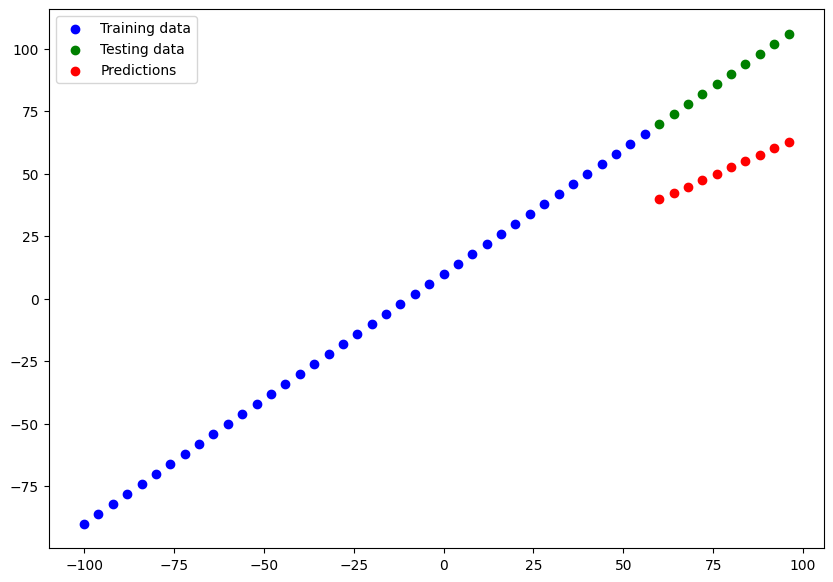

In [ ]:
# Make predictions with model_2
y_preds_2 = model_2.predict(tf.expand_dims(x_test, axis=-1))

# Plot predictions
print("Plotting predictions for model_2...")
plot_predictions(train_data=x_train, train_labels=y_train, test_data=x_test, test_labels=y_test, predictions=y_preds_2)

In [ ]:

# Evaluate model_2
print("Evaluating model_2...")
mae_2 = tf.keras.losses.MAE(y_test, tf.squeeze(y_preds_2))
mse_2 = tf.keras.losses.MSE(y_test, tf.squeeze(y_preds_2))
print(f"MAE for model_2: {tf.reduce_mean(mae_2).numpy():.2f}")
print(f"MSE for model_2: {tf.reduce_mean(mse_2).numpy():.2f}")

Evaluating model_2...
MAE for model_2: 36.76
MSE for model_2: 1368.68


### Model 3

In [ ]:
# set the random seed
tf.random.set_seed(42)

# create model_2 (2 dense layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. compile model_2
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['mse'])

# fit model_2
print("Fitting model_2...")
model_3.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=500, verbose=1)




Fitting model_2...
Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 61.5758 - mse: 5215.7324
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 56.5110 - mse: 4384.6187 
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 51.6191 - mse: 3651.4941
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 46.9112 - mse: 3004.8816
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 42.3041 - mse: 2434.8911
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 37.7469 - mse: 1932.1477
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 33.2190 - mse: 1490.9373
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 28.7228 - mse: 1109.1172
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 24.2217 - mse: 785.7800
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 19.8003 - mse: 521.4802
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 15.4095 - mse: 318.2697
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 11.2696 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Plotting predictions for model_2...


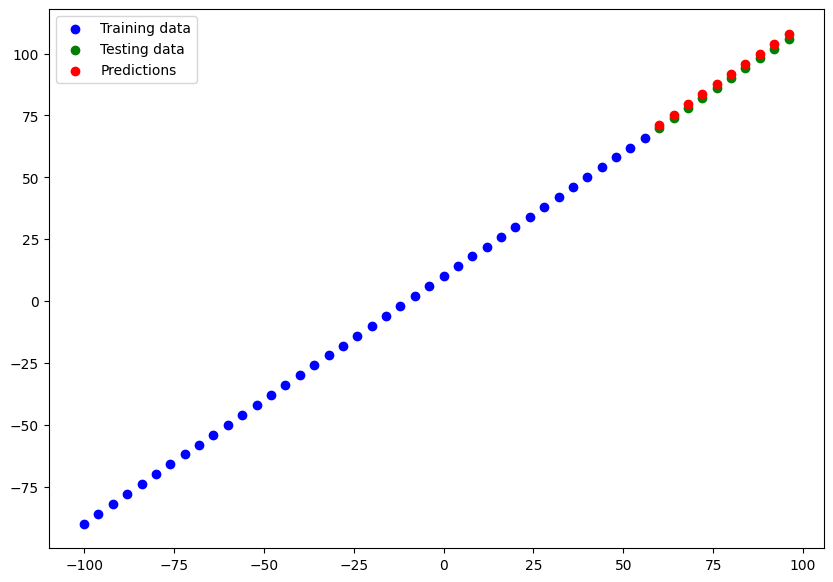

In [ ]:
# Make predictions with model_3
y_preds_3 = model_3.predict(tf.expand_dims(x_test, axis=-1))

# Plot predictions
print("Plotting predictions for model_2...")
plot_predictions(train_data=x_train, train_labels=y_train, test_data=x_test, test_labels=y_test, predictions=y_preds_3)

In [ ]:

# Evaluate model_3
print("Evaluating model_3...")
mae_3 = tf.keras.losses.MAE(y_test, tf.squeeze(y_preds_3))
mse_3 = tf.keras.losses.MSE(y_test, tf.squeeze(y_preds_3))
print(f"MAE for model_3: {tf.reduce_mean(mae_3).numpy():.2f}")
print(f"MSE for model_3: {tf.reduce_mean(mse_3).numpy():.2f}")

Evaluating model_3...
MAE for model_3: 1.62
MSE for model_3: 2.68


## Comparing the results of all our expriments



In [ ]:
import pandas as pd

# lets compare our model result using pandas datafarame

model_result = [["model_1",mae_1.numpy(),mse_1.numpy()],
                ["model_2",mae_2.numpy(),mse_2.numpy()],
                ["model_3",mae_3.numpy(),mse_3.numpy()]
                ]

all_result = pd.DataFrame(model_result, columns=["Model", "MAE", "MSE"])
display(all_result)

,Model,MAE,MSE
0,model_1,21.627136,471.373444
1,model_2,36.758709,1368.681152
2,model_3,1.620643,2.681509


# model 3 is best now

In [ ]:
model_3.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

## saving our models

saving our model allows us to use them outside of google colab such as website or mobile app.


there are two model format to save

1. The SavedModel format

2. The HDF5 format




In [ ]:
# save the model to SavedModel format

model_3.save("Best_SavedModel_Format.keras")

In [ ]:
# save model using the HDF5 format

model_3.save("best_model_HDF5_format.h5")

## Load rthe saved model andcheck its working or not

In [ ]:
# loading the model

load_model = tf.keras.models.load_model("/content/Best_SavedModel_Format.keras")
load_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [ ]:
# compare model_3 predictions with savedmodel format model predictions

model_3_preds = model_3.predict(tf.expand_dims(x_test, axis=-1))

load_model_preds  = load_model.predict(tf.expand_dims(x_test, axis=-1))

model_3_preds == load_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

# YaaAaaY.. Same Same SavedModel Working Good

In [ ]:
# loading the model HDF5 format

load_hdf5 = tf.keras.models.load_model("/content/best_model_HDF5_format.h5")

# compare model_3 predictions with savedmodel format model predictions

model_3_preds = model_3.predict(tf.expand_dims(x_test, axis=-1))

load_hdf5_preds  = load_model.predict(tf.expand_dims(x_test, axis=-1))

model_3_preds == load_hdf5_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

## A LARGER EXAMPLE

In [1]:
# Import required libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
# lets try one hot encode our dataframe so it's all numbers
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [9]:
# create x and y (features and labels)
x = insurance_one_hot.drop("charges",axis=1)
y = insurance_one_hot['charges']


In [10]:
# view x
x.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [11]:
# view y
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [12]:
# creating training and test sets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

len(x_train),len(x_test),len(y_train),len(y_test)



(1070, 268, 1070, 268)

In [20]:
import tensorflow as tf

# build a neural network (sort of like model_3 above)
tf.random.set_seed(42)

# crete a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model.compile(loss = tf.keras.losses.mae,
                        optimizer = tf.keras.optimizers.SGD(),
                        metrics=['mae'])

# fit the model
insurance_model.fit(x_train,y_train,epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8549.7793 - mae: 8549.7793  
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7594.7417 - mae: 7594.7417
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7617.4795 - mae: 7617.4795
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7772.9512 - mae: 7772.9512
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7818.3921 - mae: 7818.3921
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7549.6851 - mae: 7549.6851
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7522.7866 - mae: 7522.7866
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7786.1890 - mae: 7786.1890
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7558.0786 - mae: 7558.0786
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7550.6206 - mae: 7550.6206 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7415.6777 - mae: 7415.6777 
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

In [21]:
# check the result of model on test data

insurance_model.evaluate(x_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9338.2959 - mae: 9338.2959    


[9338.2958984375, 9338.2958984375]

## Lets improve the model by ownself

## model 2

In [41]:
# set the random seed
tf.random.set_seed(42)

# create model_2 (2 dense layers)
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(75),
    tf.keras.layers.Dense(50),
    tf.keras.layers.Dense(25),
    tf.keras.layers.Dense(1)
])

# 2. compile model
insurance_model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['mse'])

# fit model
insurance_model_2.fit(x_train, y_train, epochs=500, verbose=1)




Epoch 1/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8725.6973 - mse: 187056848.0000 
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6787.0723 - mse: 155734112.0000
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6267.7051 - mse: 145714928.0000
Epoch 4/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5431.5581 - mse: 109079296.0000
Epoch 5/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4568.9507 - mse: 54653592.0000
Epoch 6/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4003.1719 - mse: 48943684.0000
Epoch 7/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3960.1047 - mse: 52901764.0000
Epoch 8/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3845.3569 - mse: 48638380.0000
Epoch 9/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4016.4617 - mse: 46148396.0000
Epoch 10/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3761.4551 - mse: 44709184.0000
Epoch 11/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3918.5398 - mse: 43854688.0000
Epo

In [43]:
# check the result of model on test data

insurance_model_2.evaluate(x_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3308.2654 - mse: 41184992.0000  


[3308.265380859375, 41184992.0]

## model 3

In [51]:
# set the random seed
tf.random.set_seed(42)

# create model_3 (dense layers)
insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(75),
    tf.keras.layers.Dense(50),
    tf.keras.layers.Dense(25),
    tf.keras.layers.Dense(1)
])

# 2. compile model
insurance_model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.009),
                metrics=['mae'])

# fit model
history = insurance_model_3.fit(x_train, y_train, epochs=200, verbose=1)



Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8669.6973 - mae: 8669.6973  
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6757.7119 - mae: 6757.7119
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6468.7446 - mae: 6468.7446
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5961.6470 - mae: 5961.6470
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4576.0371 - mae: 4576.0371
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3955.9519 - mae: 3955.9519
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4027.5696 - mae: 4027.5696
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3996.3337 - mae: 3996.3337
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3793.5920 - mae: 3793.5920
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3907.9246 - mae: 3907.9246
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3879.0400 - mae: 3879.0400
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

In [52]:
# check the result of model on test data

insurance_model_3.evaluate(x_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3381.2578 - mae: 3381.2578  


[3381.2578125, 3381.2578125]

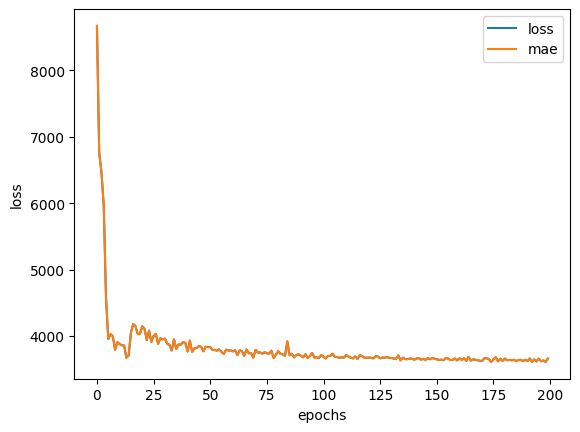

In [54]:
# plot history (also known as a loss curve or a training curve)


pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel('epochs');

## Lets normalize the data

# PREPROCESSING

<Axes: ylabel='Frequency'>

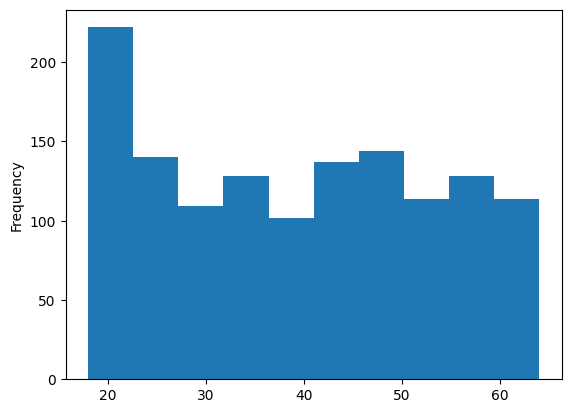

In [55]:
x['age'].plot(kind='hist')

<Axes: ylabel='Frequency'>

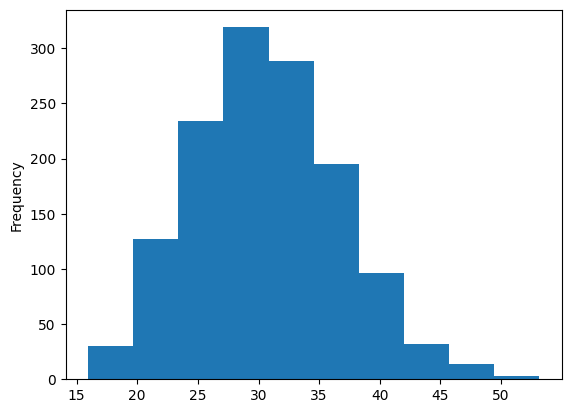

In [56]:
x['bmi'].plot(kind='hist')

## Preprocessing Data (Normalization And Standardization)


in terms of scaling values, nural network tend to prefer normalization.

if you are sure on which to use you could try both and see with perform better



In [57]:
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


to prepare our data, we can borrow a few classes form sklean

In [62]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# create a column transformer
ct = make_column_transformer(
    (MinMaxScaler(), ['age','bmi','children']), # turn all values into in these column between 0 and 1
    (OneHotEncoder(handle_unknown='ignore'),['sex','smoker','region'])
)

# create x and y
x = insurance.drop("charges",axis=1)
y = insurance["charges"]


# build our train and test sets

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# fit the col transformer to our training data
ct.fit(x_train)

# transform training and test data with normalization (minmaxscalar) and OneHotEncoder
x_train_normal = ct.transform(x_train)
x_test_normal = ct.transform(x_test)

In [63]:
# what does our data look like now?
x_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [66]:
x_train.shape , x_train_normal.shape

((1070, 6), (1070, 11))

In [69]:
# set the random seed
tf.random.set_seed(42)

# create model_4 (dense layers)
insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(50),
    tf.keras.layers.Dense(25),
    tf.keras.layers.Dense(1)
])

# 2. compile model
insurance_model_4.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
                metrics=['mae'])

# fit model
insurance_model_4.fit(x_train_normal, y_train, epochs=100, verbose=1)



Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8247.2324 - mae: 8247.2324  
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4283.6245 - mae: 4283.6245
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4022.1548 - mae: 4022.1548
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4333.2759 - mae: 4333.2759
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4275.9321 - mae: 4275.9321
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4204.6377 - mae: 4204.6377
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4131.3687 - mae: 4131.3687
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4020.8650 - mae: 4020.8650
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3805.4934 - mae: 3805.4934
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3815.5811 - mae: 3815.5811
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3836.4761 - mae: 3836.4761
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste